# Limpieza y Análisis Exploratorio — VIII Encuesta de Microemprendimiento (EME)

Este notebook reproduce el proceso de limpieza que transforma la **Base de Datos Full** en el **dataset_limpio**, y luego realiza un análisis exploratorio de las variables seleccionadas.

**Fuente:** VIII EME (Encuesta de Microemprendimiento), Chile.  
**Variables resultantes:** id, región, sexo, tramo etario, informalidad, nivel educativo, lugar de trabajo, financiamiento inicial, motivación, tramos de ganancias, rama económica, ganancia final.

## 0. Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga de datos

In [ ]:
# ── Ajusta las rutas según donde estén los archivos ──────────────────────────
RUTA_FULL   = 'Base_de_Datos_Full_VIII_EME_CSV.csv'
RUTA_SALIDA = 'dataset_limpio_generado.csv'

df = pd.read_csv(RUTA_FULL, encoding='latin1')

print(f'Dimensiones originales: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head(3)

Dimensiones originales: 7,170 filas × 669 columnas


,Unnamed: 0,id,region,sexo,tramo_etario,est_conyugal,nacionalidad,proveedor,a1,a2,...,financiamiento_capacitacion,razones_no_capacitacion,antiguedad_laboral,financiamiento_inicial,fin_pres_pri,razon_no_cred,prevalencia_ac_lab,estrato,conglomerado,factor_eme
0,1,36189105,1,1,3,2,1,1,1,NaN,...,1.0,NaN,5.0,3.0,NaN,1.0,NaN,1200120,140220003,69.159258
1,2,61746634,1,1,6,6,1,1,1,NaN,...,1.0,NaN,5.0,1.0,NaN,6.0,NaN,1200120,140220003,60.322766
2,3,30871308,3,2,6,6,1,1,1,NaN,...,1.0,NaN,5.0,4.0,2.0,5.0,NaN,3100120,310320009,41.219795


## 2. Limpieza — Selección de columnas relevantes

De las 669 columnas originales se conservan solo las necesarias para el análisis. Las demás son sub-ítems de la encuesta o variables auxiliares de diseño muestral.

In [ ]:
COLUMNAS = [
    'id',
    'region',
    'sexo',
    'tramo_etario',
    'informalidad',          # 0 = Formal, 1 = Informal
    'a2',                    # nivel educativo (codificado)
    'lugar_trabajo',         # lugar donde ejerce la actividad
    'financiamiento_inicial',
    'motivacion',
    'tramos_ganancias',
    'c1_caenes_1d_red',      # rama económica (CAENES 1 dígito)
    'ganancia_final',
]

df = df[COLUMNAS].copy()
print(f'Columnas seleccionadas: {df.shape[1]}')
print(f'Filas: {df.shape[0]:,}')

Columnas seleccionadas: 12
Filas: 7,170


## 3. Limpieza — Recodificación de variables categóricas

En la base original las categorías están codificadas numéricamente. A continuación se reemplazan por sus etiquetas según el libro de códigos de la VIII EME.

In [ ]:
# ── 3.1 Región ───────────────────────────────────────────────────────────────
region_map = {
    1:  'Tarapacá',
    2:  'Antofagasta',
    3:  'Atacama',
    4:  'Coquimbo',
    5:  'Valparaíso',
    6:  "O'Higgins",
    7:  'Maule',
    8:  'Biobío',
    9:  'La Araucanía',
    10: 'Los Lagos',
    11: 'Aysén',
    12: 'Magallanes',
    13: 'Metropolitana',
    14: 'Los Ríos',
    15: 'Arica y Parinacota',
    16: 'Ñuble',
}
df['region'] = df['region'].map(region_map)


3.2 Sexo:

In [ ]:
sexo_map = {1: 'Hombre', 2: 'Mujer'}
df['sexo'] = df['sexo'].map(sexo_map)


3.3 Tramo etario:

In [ ]:
tramo_map = {
    1: '15 a 24 años',
    2: '25 a 34 años',
    3: '35 a 44 años',
    4: '45 a 54 años',
    5: '55 a 64 años',
    6: '65 años o más',
}
df['tramo_etario'] = df['tramo_etario'].map(tramo_map)

3.4 Informalidad:

In [ ]:
informalidad_map = {0: 'Formal', 1: 'Informal'}
df['informalidad'] = df['informalidad'].map(informalidad_map)

3.5 Nivel educativo (a2):

In [ ]:
nivel_educ_map = {
    1:  'Sin instrucción / Básica incompleta',
    2:  'Básica completa / Media incompleta',
    3:  'Media completa',
    4:  'Superior incompleta (IP/CFT/Univ)',
    5:  'Superior completa (IP/CFT)',
    6:  'Superior completa (Universitaria o más)',
    7:  'Postgrado',
    8:  'Educación especial',
    9:  'Sin instrucción / Básica incompleta',  # agrupado
    77: None,   # No sabe → NaN
    99: None,   # No responde → NaN
}
df['nivel_educativo'] = df['a2'].map(nivel_educ_map)
df.drop(columns=['a2'], inplace=True)

3.6 Lugar de trabajo:

In [ ]:
lugar_map = {
    1: 'En su propio hogar',
    2: 'En el hogar del cliente',
    3: 'Local/Oficina/Taller establecido',
    4: 'En la vía pública / Kiosco',
    5: 'Vehículo',
    6: 'No tiene un lugar fijo',
    7: 'Predio agrícola',
    8: 'Obra en construcción',
    9: 'Otro lugar fijo fuera del hogar',
}
df['lugar_trabajo'] = df['lugar_trabajo'].map(lugar_map)

3.7 Financiamiento inicial:

In [ ]:
financ_map = {
    1: 'Solo ahorros/recursos propios',
    2: 'Préstamos de familiares/amigos',
    3: 'Financiamiento formal (Bancos/Instituciones)',
    4: 'Subsidios públicos / Fondos del Estado',
}
df['financiamiento_inicial'] = df['financiamiento_inicial'].map(financ_map)

3.8 Motivación:

In [ ]:
motiv_map = {
    1:  'Tradición familiar',
    2:  'Oportunidad (Aumentar ingresos/Independencia)',
    3:  'Necesidad (Desempleo/Falta de oportunidades)',
    4:  'Complementar ingresos',
    77: 'Otra razón',
    99: None,   # No responde → NaN
}
df['motivacion'] = df['motivacion'].map(motiv_map)

3.9 Tramos de ganancias:

In [ ]:
tramos_map = {
    1: 'Menos de $300.000',
    2: 'De $300.000 a $600.000',
    3: 'De $600.000 a $1.000.000',
    4: 'De $1.000.000 a $1.500.000',
    5: 'De $1.500.000 a $2.500.000',
    6: 'Más de $2.500.000',
}
df['tramos_ganancias'] = df['tramos_ganancias'].map(tramos_map)

3.10 Rama económica (caenes_1d):

In [ ]:
rama_map = {
    1: 'Agricultura, silvicultura y pesca',
    2: 'Explotación de minas',
    3: 'Industrias manufactureras',
    4: 'Suministro de electricidad y agua',
    5: 'Construcción',
    6: 'Comercio',
}
df['rama_economica'] = df['c1_caenes_1d_red'].map(rama_map)
df.drop(columns=['c1_caenes_1d_red'], inplace=True)

In [ ]:
print('Recodificación completada.')
df.head(3)

Recodificación completada.


,id,region,sexo,tramo_etario,informalidad,lugar_trabajo,financiamiento_inicial,motivacion,tramos_ganancias,ganancia_final,nivel_educativo,rama_economica
0,36189105,Tarapacá,Hombre,35 a 44 años,Informal,Local/Oficina/Taller establecido,3.0,Tradición familiar,Menos de $300.000,110000.0,NaN,"Agricultura, silvicultura y pesca"
1,61746634,Tarapacá,Hombre,65 años o más,Formal,En la vía pública / Kiosco,1.0,Tradición familiar,Menos de $300.000,30000.0,NaN,Explotación de minas
2,30871308,Atacama,Mujer,65 años o más,Formal,Vehículo,4.0,Necesidad (Desempleo/Falta de oportunidades),De $600.000 a $1.000.000,1300000.0,NaN,Suministro de electricidad y agua


## 4. Limpieza — Reordenar columnas y ajustar tipos

In [ ]:
# Orden final de columnas (igual al dataset_limpio de referencia)
ORDEN = [
    'id', 'region', 'sexo', 'tramo_etario', 'informalidad',
    'nivel_educativo', 'lugar_trabajo', 'financiamiento_inicial',
    'motivacion', 'tramos_ganancias', 'rama_economica', 'ganancia_final'
]
df = df[ORDEN]

# ganancia_final a numérico (puede tener strings por filas mal formateadas)
df['ganancia_final'] = pd.to_numeric(df['ganancia_final'], errors='coerce')

# Tramo etario como categórico ordenado
orden_tramos = ['15 a 24 años', '25 a 34 años', '35 a 44 años',
                '45 a 54 años', '55 a 64 años', '65 años o más']
df['tramo_etario'] = pd.Categorical(df['tramo_etario'], categories=orden_tramos, ordered=True)

print(df.dtypes)
print(f'\nDimensiones finales: {df.shape[0]:,} filas × {df.shape[1]} columnas')

id                           int64
region                      object
sexo                        object
tramo_etario              category
informalidad                object
nivel_educativo             object
lugar_trabajo               object
financiamiento_inicial     float64
motivacion                  object
tramos_ganancias            object
rama_economica              object
ganancia_final             float64
dtype: object

Dimensiones finales: 7,170 filas × 12 columnas


## 5. Valores faltantes — interpretación según el Libro de Códigos VIII EME

Los `NaN` en el dataset limpio tienen **tres orígenes distintos**, según el libro de códigos del INE:

| Variable | Origen de los nulos | Detalle según libro de códigos |
|---|---|---|
| `region` | Variable completa → sin nulos | N/A — 7.170 valores válidos |
| `sexo` | Sin nulos | N/A — 7.170 valores válidos |
| `tramo_etario` | Sin nulos | N/A — 7.170 valores válidos |
| `informalidad` | Variable construida → nulos son personas sin dato de informalidad | N/A en el libro; 6.763 valores válidos (407 nulos posibles) |
| `nivel_educativo` | Códigos 77 (No sabe) y 99 (No responde) → convertidos a `NaN` | Pregunta A2: «Motivo cambio situación laboral» — aplica solo a quienes cerraron el negocio |
| `lugar_trabajo` | Variable construida | N/A — 6.763 valores válidos |
| `financiamiento_inicial` | Variable construida | N/A — 6.763 valores válidos |
| `motivacion` | Código 99 (No responde) → convertido a `NaN` | 6.763 valores válidos |
| `tramos_ganancias` | Variable construida | N/A — 6.763 valores válidos |
| `rama_economica` | Variable `c1_caenes_1d_red` — encuestados sin actividad clasificable | N/A en libro; 6.759 valores válidos (411 nulos posibles) |
| `ganancia_final` | Variable cuantitativa construida por metodología de depuración del INE | N/A — 6.763 valores válidos; los nulos son personas excluidas de la depuración |

> **Nota general:** El libro de códigos indica que los códigos de no-respuesta estándar son `88 = No sabe` y `99 = No responde`.
En el proceso de limpieza estos valores se recodifican como `NaN` para no contaminar los análisis numéricos.

Total filas:           7,170
Total columnas:        12
Celdas nulas totales:  9,638



,N nulos,% nulos,N válidos,Dtype,Origen del nulo (libro de códigos)
nivel_educativo,6783,94.60,387,object,Pregunta A2 — nulos incluyen cód. 77 (No sabe)...
motivacion,413,5.76,6757,object,Motivación para emprender — nulos = cód. 99 (N...
informalidad,407,5.68,6763,object,Variable construida — nulos = sin clasificació...
lugar_trabajo,407,5.68,6763,object,Variable construida — nulos = sin clasificació...
financiamiento_inicial,407,5.68,6763,float64,Variable construida — nulos = sin clasificació...
tramos_ganancias,407,5.68,6763,object,Tramos en sueldos mínimos — variable construid...
rama_economica,407,5.68,6763,object,CAENES 1 dígito (c1_caenes_1d_red) — nulos = s...
ganancia_final,407,5.68,6763,float64,Ganancia mensual depurada por INE — nulos = ex...
tramo_etario,0,0.00,7170,category,Edad tramificada — sin nulos (7.170 válidos)
sexo,0,0.00,7170,object,Sexo informante — sin nulos (7.170 válidos)


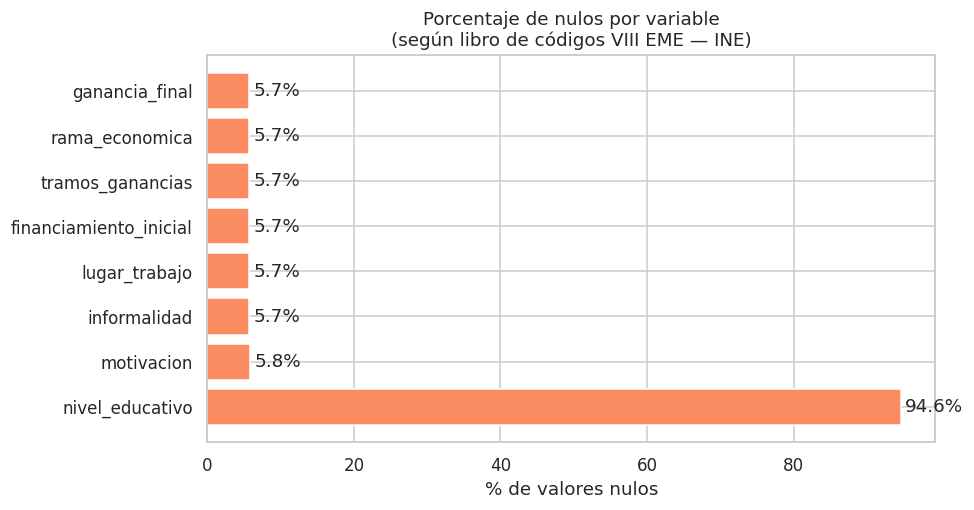

In [ ]:
# ── Diagnóstico de valores nulos con contexto del libro de códigos ────────────

# Descripción de cada variable según el libro de códigos
descripcion_vars = {
    'id':                     'Identificador único — sin nulos esperados',
    'region':                 'Región — sin nulos (7.170 válidos)',
    'sexo':                   'Sexo informante — sin nulos (7.170 válidos)',
    'tramo_etario':           'Edad tramificada — sin nulos (7.170 válidos)',
    'informalidad':           'Variable construida — nulos = sin clasificación (esperados ~407)',
    'nivel_educativo':        'Pregunta A2 — nulos incluyen cód. 77 (No sabe) y 99 (No responde); solo aplica a quienes cerraron el negocio',
    'lugar_trabajo':          'Variable construida — nulos = sin clasificación (esperados ~407)',
    'financiamiento_inicial': 'Variable construida — nulos = sin clasificación (esperados ~407)',
    'motivacion':             'Motivación para emprender — nulos = cód. 99 (No responde)',
    'tramos_ganancias':       'Tramos en sueldos mínimos — variable construida (esperados ~407)',
    'rama_economica':         'CAENES 1 dígito (c1_caenes_1d_red) — nulos = sin actividad clasificable (~411)',
    'ganancia_final':         'Ganancia mensual depurada por INE — nulos = excluidos de la metodología',
}

# Resumen general
print(f'Total filas:           {df.shape[0]:,}')
print(f'Total columnas:        {df.shape[1]}')
print(f'Celdas nulas totales:  {df.isnull().sum().sum():,}\n')

# Tabla detallada
nulos = pd.DataFrame({
    'N nulos':      df.isnull().sum(),
    '% nulos':      (df.isnull().mean() * 100).round(2),
    'N válidos':    df.notnull().sum(),
    'Dtype':        df.dtypes.astype(str),
    'Origen del nulo (libro de códigos)': pd.Series(descripcion_vars),
})
nulos = nulos.sort_values('% nulos', ascending=False)
display(nulos)

# Visualización solo de variables con nulos
nulos_plot = nulos[nulos['% nulos'] > 0]
if len(nulos_plot) > 0:
    fig, ax = plt.subplots(figsize=(9, max(3, len(nulos_plot) * 0.6)))
    bars = ax.barh(nulos_plot.index, nulos_plot['% nulos'],
                   color=sns.color_palette('Set2')[1])
    ax.bar_label(bars, fmt='%.1f%%', padding=3)
    ax.set_xlabel('% de valores nulos')
    ax.set_title('Porcentaje de nulos por variable\n(según libro de códigos VIII EME — INE)')
    plt.tight_layout()
    plt.show()
else:
    print('No hay valores nulos en el dataset.')

5.1 Conteo de nulos totales por columna tras la limpieza

Nulos totales en el dataset limpio: 9,638



,N nulos,% nulos,N válidos,Criterio
nivel_educativo,6783,94.60,387,Mantener NaN — no-respuesta válida (cód. 77/99)
motivacion,413,5.76,6757,Mantener NaN — no responde (cód. 99)
informalidad,407,5.68,6763,Mantener NaN — sin clasificación posible
lugar_trabajo,407,5.68,6763,Mantener NaN — sin clasificación posible
financiamiento_inicial,407,5.68,6763,Mantener NaN — sin clasificación posible
tramos_ganancias,407,5.68,6763,Mantener NaN — sin clasificación posible
rama_economica,407,5.68,6763,Mantener NaN — sin actividad clasificable
ganancia_final,407,5.68,6763,Mantener NaN — excluidos por metodología INE
tramo_etario,0,0.00,7170,Sin nulos
sexo,0,0.00,7170,Sin nulos


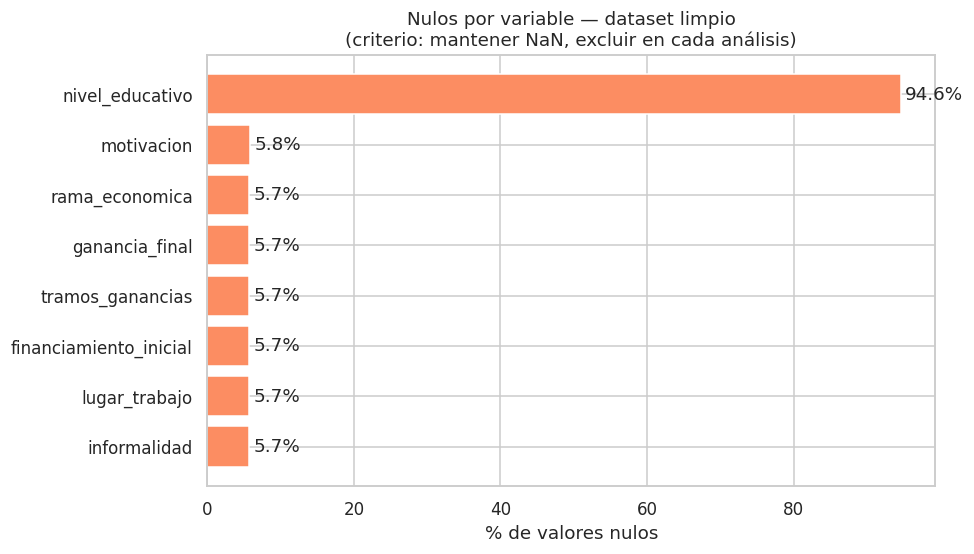

In [ ]:
nulos_finales = pd.DataFrame({
    'N nulos':   df.isnull().sum(),
    '% nulos':   (df.isnull().mean() * 100).round(2),
    'N válidos': df.notnull().sum(),
    'Criterio':  pd.Series({
        'id':                     'Sin nulos',
        'region':                 'Sin nulos',
        'sexo':                   'Sin nulos',
        'tramo_etario':           'Sin nulos',
        'informalidad':           'Mantener NaN — sin clasificación posible',
        'nivel_educativo':        'Mantener NaN — no-respuesta válida (cód. 77/99)',
        'lugar_trabajo':          'Mantener NaN — sin clasificación posible',
        'financiamiento_inicial': 'Mantener NaN — sin clasificación posible',
        'motivacion':             'Mantener NaN — no responde (cód. 99)',
        'tramos_ganancias':       'Mantener NaN — sin clasificación posible',
        'rama_economica':         'Mantener NaN — sin actividad clasificable',
        'ganancia_final':         'Mantener NaN — excluidos por metodología INE',
    })
})

print(f'Nulos totales en el dataset limpio: {df.isnull().sum().sum():,}\n')
display(nulos_finales.sort_values('% nulos', ascending=False))

# Gráfico
nulos_plot = nulos_finales[nulos_finales['N nulos'] > 0].sort_values('% nulos')
fig, ax = plt.subplots(figsize=(9, max(3, len(nulos_plot) * 0.65)))
bars = ax.barh(nulos_plot.index, nulos_plot['% nulos'],
               color=sns.color_palette('Set2')[1])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_xlabel('% de valores nulos')
ax.set_title('Nulos por variable — dataset limpio\n(criterio: mantener NaN, excluir en cada análisis)')
plt.tight_layout()
plt.show()

## 6. Exportar dataset limpio

In [ ]:
df.to_csv(RUTA_SALIDA, index=False, encoding='utf-8')
print(f'Dataset exportado → {RUTA_SALIDA}')
print(f'Filas: {len(df):,} | Columnas: {df.shape[1]}')

Dataset exportado → dataset_limpio_generado.csv
Filas: 7,170 | Columnas: 12


---
# Análisis Exploratorio de Datos (EDA)

A partir de aquí se trabaja con el dataset limpio.

In [ ]:
print('=== Resumen estadístico — ganancia_final ===')
display(df[['ganancia_final']].describe(percentiles=[.25, .5, .75, .9]).T.round(0))

=== Resumen estadístico — ganancia_final ===


,count,mean,std,min,25%,50%,75%,90%,max
ganancia_final,6763.0,746704.0,2845306.0,-90000000.0,150000.0,400000.0,715000.0,1500000.0,120000000.0


EDA 1. Estadístico descriptivo completo:

In [ ]:
gf_valida = df[df['ganancia_final'] > 0]['ganancia_final']

desc = gf_valida.describe(percentiles=[.25, .5, .75, .9])
desc['moda']   = gf_valida.mode()[0]
desc['mediana']= gf_valida.median()
desc['CV (%)'] = (gf_valida.std() / gf_valida.mean() * 100).round(1)

print('=== Estadísticos de ganancia_final (valores > 0) ===')
display(
    desc.rename({
        'count':'N válidos', 'mean':'Media', 'std':'Desv. estándar',
        'min':'Mínimo', '25%':'P25', '50%':'Mediana (P50)',
        '75%':'P75', '90%':'P90', 'max':'Máximo'
    }).to_frame('ganancia_final (CLP)').applymap(
        lambda x: f'{x:,.0f}' if isinstance(x, float) else x
    )
)

# ── Describe categórico ──────────────────────────────────────────────────────
print('\n=== Estadísticos categóricos (moda y frecuencia) ===')
cat_cols = ['sexo','tramo_etario','informalidad','nivel_educativo',
            'lugar_trabajo','financiamiento_inicial','motivacion',
            'tramos_ganancias','rama_economica']
rows = []
for col in cat_cols:
    vc = df[col].value_counts(dropna=True)
    rows.append({
        'Variable':         col,
        'N válidos':        df[col].notna().sum(),
        'N nulos':          df[col].isna().sum(),
        'N categorías':     df[col].nunique(),
        'Moda':             vc.index[0] if len(vc) else 'N/A',
        'Freq. moda':       vc.iloc[0] if len(vc) else 0,
        '% moda':           f"{vc.iloc[0]/df[col].notna().sum()*100:.1f}%" if len(vc) else 'N/A',
    })
display(pd.DataFrame(rows).set_index('Variable'))

=== Estadísticos de ganancia_final (valores > 0) ===


,ganancia_final (CLP)
N válidos,"6,531"
Media,"797,336"
Desv. estándar,"2,655,504"
Mínimo,3
P25,"150,000"
Mediana (P50),"400,000"
P75,"750,000"
P90,"1,500,000"
Máximo,"120,000,000"
moda,"500,000"



=== Estadísticos categóricos (moda y frecuencia) ===


,N válidos,N nulos,N categorías,Moda,Freq. moda,% moda
Variable,,,,,,
sexo,7170,0,2,Hombre,4095,57.1%
tramo_etario,7170,0,6,55 a 64 años,1829,25.5%
informalidad,6763,407,2,Informal,3844,56.8%
nivel_educativo,387,6783,8,Superior incompleta (IP/CFT/Univ),95,24.5%
lugar_trabajo,6763,407,9,No tiene un lugar fijo,1431,21.2%
financiamiento_inicial,6763,407,4,1.0,4316,63.8%
motivacion,6757,413,5,Oportunidad (Aumentar ingresos/Independencia),3440,50.9%
tramos_ganancias,6763,407,6,Menos de $300.000,4356,64.4%
rama_economica,6763,407,6,Suministro de electricidad y agua,1932,28.6%


### 6.1 Distribución por sexo e informalidad

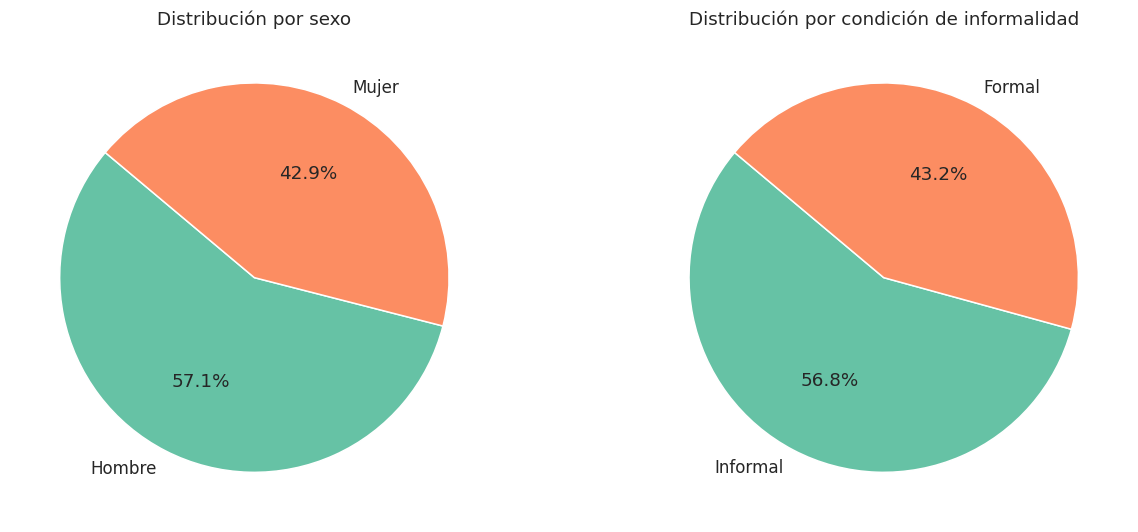

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Sexo
v_sexo = df['sexo'].value_counts()
axes[0].pie(v_sexo, labels=v_sexo.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 2), startangle=140)
axes[0].set_title('Distribución por sexo')

# Informalidad
v_inf = df['informalidad'].value_counts()
axes[1].pie(v_inf, labels=v_inf.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 2), startangle=140)
axes[1].set_title('Distribución por condición de informalidad')

plt.tight_layout()
plt.show()

### 6.2 Distribución por tramo etario

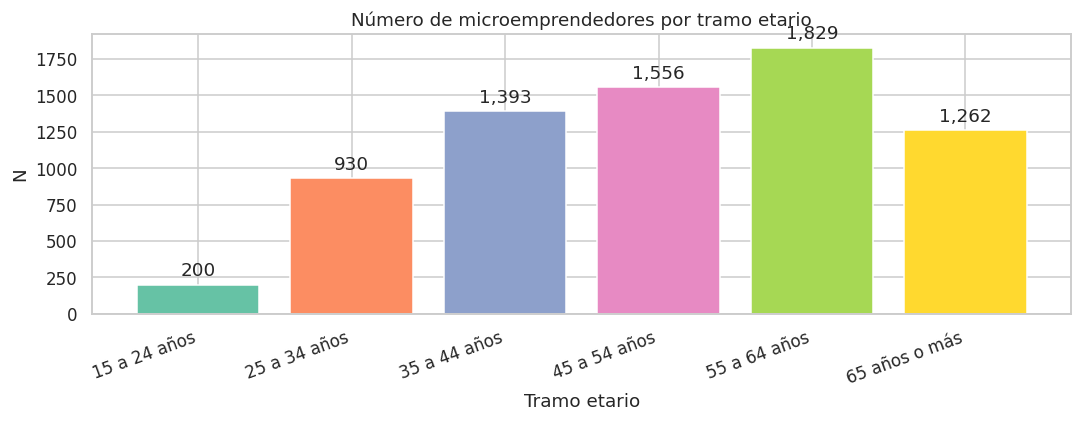

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
conteo = df['tramo_etario'].value_counts().sort_index()
bars = ax.bar(conteo.index.astype(str), conteo.values,
              color=sns.color_palette('Set2', len(conteo)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Número de microemprendedores por tramo etario')
ax.set_xlabel('Tramo etario')
ax.set_ylabel('N')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 6.3 Distribución por región

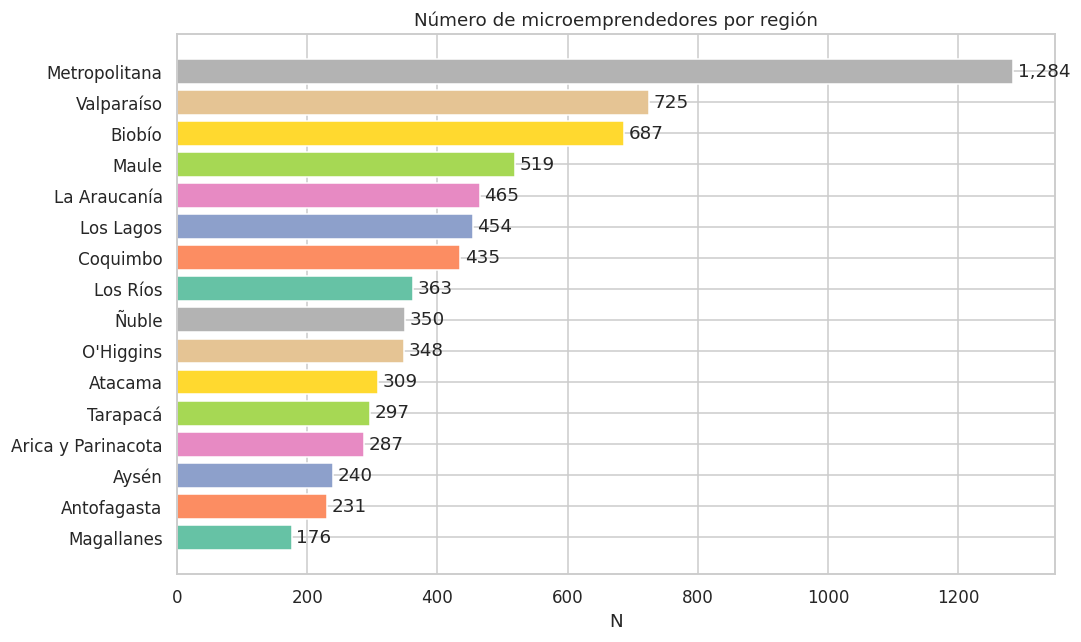

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
conteo_reg = df['region'].value_counts().sort_values()
bars = ax.barh(conteo_reg.index, conteo_reg.values,
               color=sns.color_palette('Set2', len(conteo_reg)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Número de microemprendedores por región')
ax.set_xlabel('N')
plt.tight_layout()
plt.show()

### 6.4 Nivel educativo

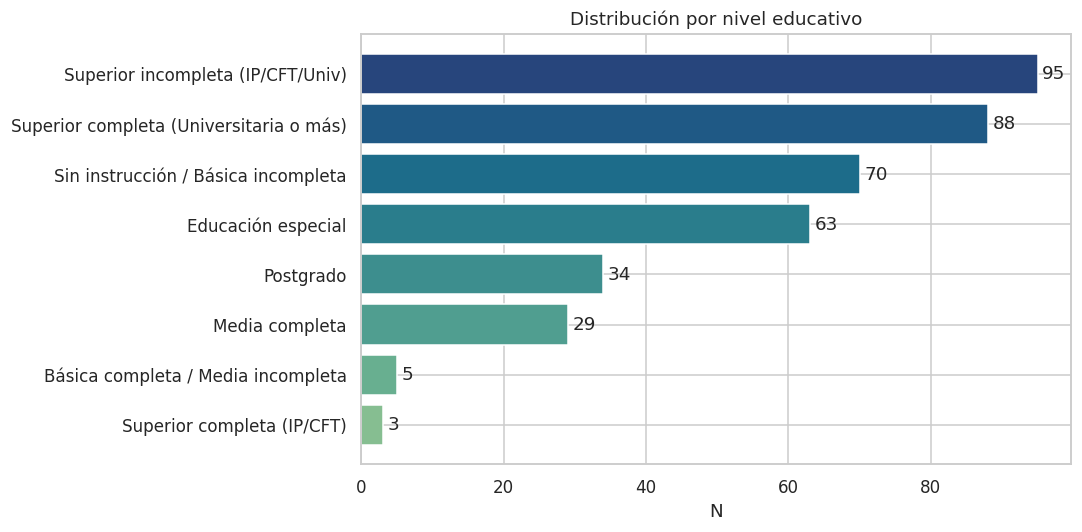

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
conteo_educ = df['nivel_educativo'].value_counts().sort_values()
bars = ax.barh(conteo_educ.index, conteo_educ.values,
               color=sns.color_palette('crest', len(conteo_educ)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Distribución por nivel educativo')
ax.set_xlabel('N')
plt.tight_layout()
plt.show()

### 6.5 Rama económica

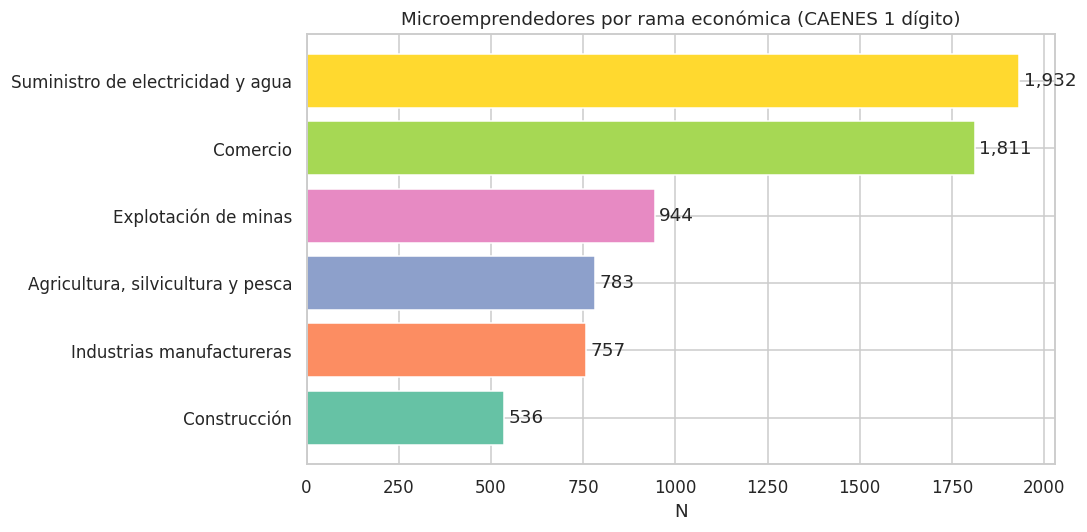

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
conteo_rama = df['rama_economica'].value_counts().sort_values()
bars = ax.barh(conteo_rama.index, conteo_rama.values,
               color=sns.color_palette('Set2', len(conteo_rama)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_title('Microemprendedores por rama económica (CAENES 1 dígito)')
ax.set_xlabel('N')
plt.tight_layout()
plt.show()

### 6.6 Motivación para emprender

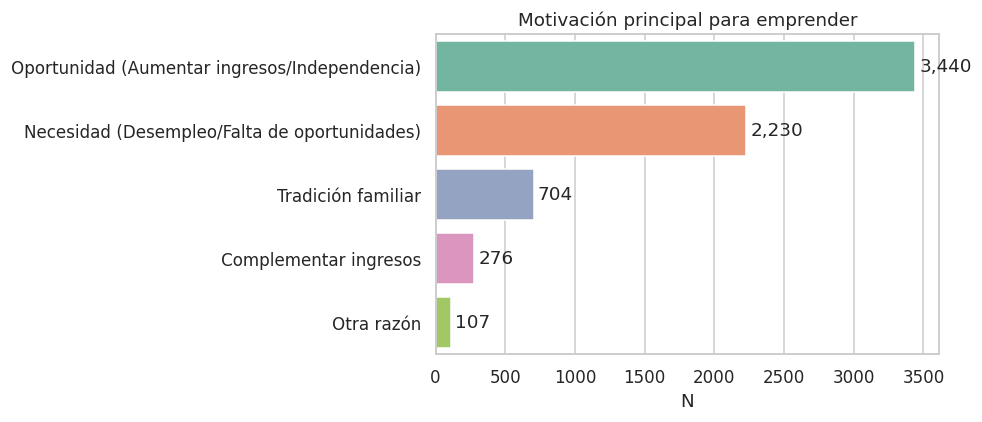

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
conteo_mot = df['motivacion'].value_counts().sort_values(ascending=False)
sns.barplot(x=conteo_mot.values, y=conteo_mot.index, ax=ax, palette='Set2')
for i, v in enumerate(conteo_mot.values):
    ax.text(v + 30, i, f'{v:,}', va='center')
ax.set_title('Motivación principal para emprender')
ax.set_xlabel('N')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 6.7 Tramos de ganancias

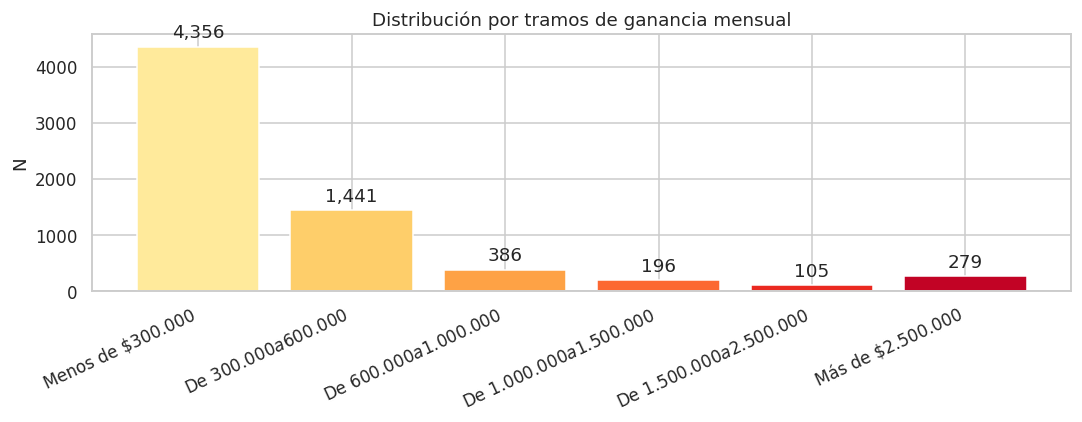

In [ ]:
orden_ganancias = [
    'Menos de $300.000', 'De $300.000 a $600.000', 'De $600.000 a $1.000.000',
    'De $1.000.000 a $1.500.000', 'De $1.500.000 a $2.500.000', 'Más de $2.500.000'
]
conteo_tramos = (df['tramos_ganancias']
                 .value_counts()
                 .reindex(orden_ganancias, fill_value=0))

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(len(conteo_tramos)), conteo_tramos.values,
              color=sns.color_palette('YlOrRd', len(conteo_tramos)))
ax.bar_label(bars, fmt='{:,.0f}', padding=3)
ax.set_xticks(range(len(conteo_tramos)))
ax.set_xticklabels(conteo_tramos.index, rotation=25, ha='right')
ax.set_title('Distribución por tramos de ganancia mensual')
ax.set_ylabel('N')
plt.tight_layout()
plt.show()

### 6.8 Ganancia final — distribución (sin outliers extremos)

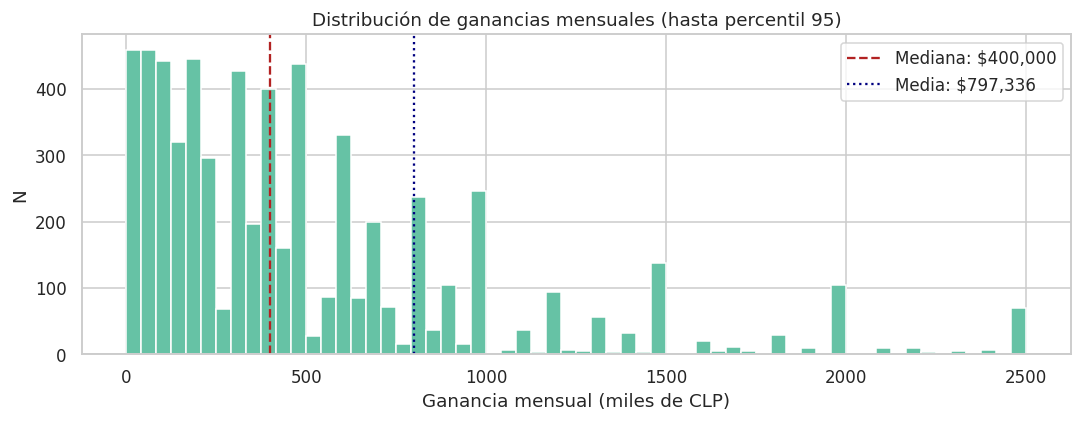

Mediana: $400,000 CLP
Media:   $797,336 CLP
Valores negativos (inconsistencias): 142


In [ ]:
# Eliminar valores negativos o nulos para la visualización (son inconsistencias de la encuesta)
gf = df.loc[df['ganancia_final'] > 0, 'ganancia_final']
p95 = gf.quantile(0.95)
gf_recortada = gf[gf <= p95]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(gf_recortada / 1_000, bins=60, color=sns.color_palette('Set2')[0], edgecolor='white')
ax.axvline(gf.median() / 1_000, color='firebrick', linestyle='--', label=f'Mediana: ${gf.median():,.0f}')
ax.axvline(gf.mean() / 1_000, color='navy', linestyle=':', label=f'Media: ${gf.mean():,.0f}')
ax.set_title('Distribución de ganancias mensuales (hasta percentil 95)')
ax.set_xlabel('Ganancia mensual (miles de CLP)')
ax.set_ylabel('N')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mediana: ${gf.median():,.0f} CLP')
print(f'Media:   ${gf.mean():,.0f} CLP')
print(f'Valores negativos (inconsistencias): {(df["ganancia_final"] < 0).sum()}')

### 6.9 Ganancia mediana por sexo y tramo etario

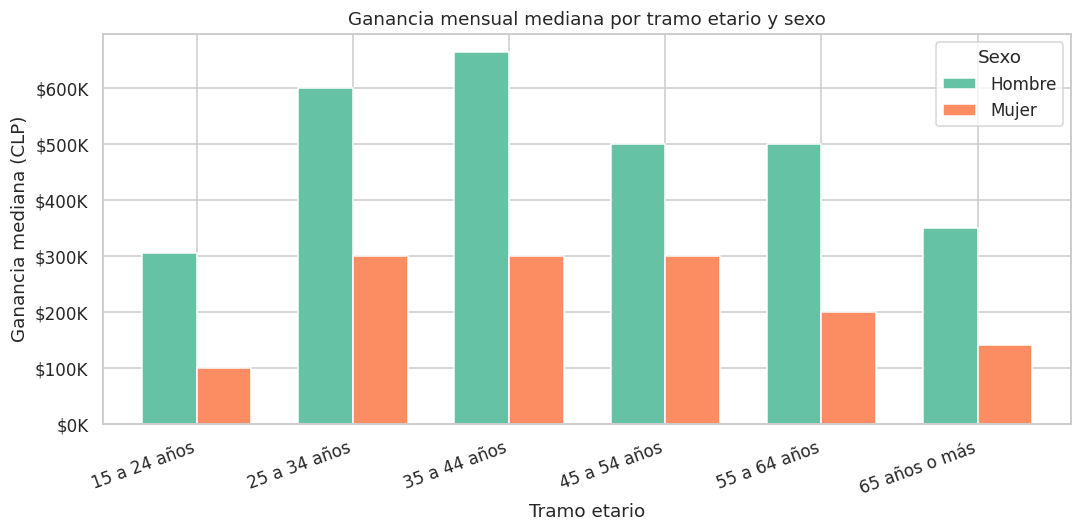

In [ ]:
df_pos = df[df['ganancia_final'] > 0].copy()

pivot = (df_pos.groupby(['tramo_etario', 'sexo'], observed=True)['ganancia_final']
         .median()
         .unstack('sexo'))

fig, ax = plt.subplots(figsize=(10, 5))
pivot.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', 2),
           width=0.7, edgecolor='white')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.set_title('Ganancia mensual mediana por tramo etario y sexo')
ax.set_xlabel('Tramo etario')
ax.set_ylabel('Ganancia mediana (CLP)')
ax.legend(title='Sexo')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 6.10 Informalidad por rama económica

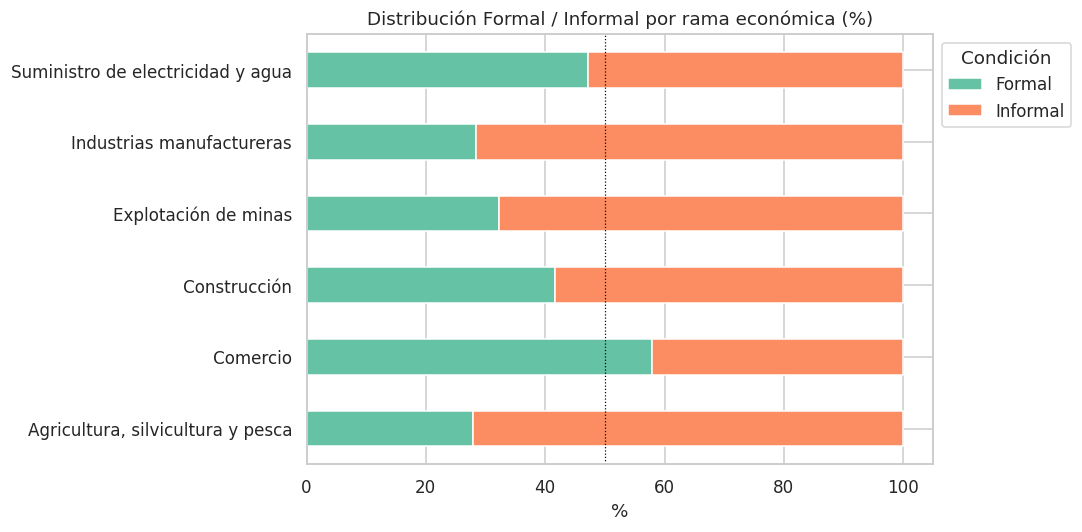

In [ ]:
tbl = (df.groupby(['rama_economica', 'informalidad'])
         .size()
         .unstack(fill_value=0))
tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
tbl_pct.plot(kind='barh', stacked=True, ax=ax,
             color=sns.color_palette('Set2', 2), edgecolor='white')
ax.set_title('Distribución Formal / Informal por rama económica (%)')
ax.set_xlabel('%')
ax.set_ylabel('')
ax.legend(title='Condición', bbox_to_anchor=(1, 1))
ax.axvline(50, color='black', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

EDA 2. Nivel de informalidad según sexo:

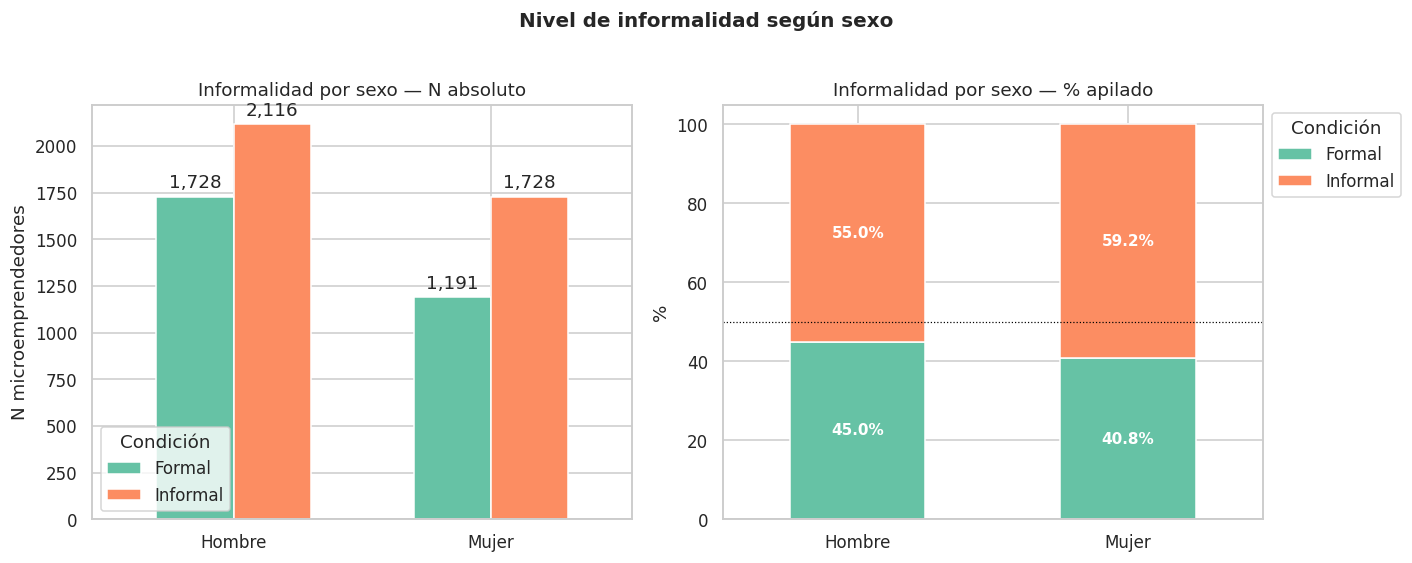

In [ ]:
tbl_inf = (df.groupby(['sexo', 'informalidad'], observed=True)
             .size()
             .unstack(fill_value=0))
tbl_inf_pct = tbl_inf.div(tbl_inf.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colores = sns.color_palette('Set2', 2)

# Izquierda: valores absolutos
tbl_inf.plot(kind='bar', ax=axes[0], color=colores, edgecolor='white', width=0.6)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='{:,.0f}', padding=3)
axes[0].set_title('Informalidad por sexo — N absoluto')
axes[0].set_xlabel('')
axes[0].set_ylabel('N microemprendedores')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Condición')

# Derecha: porcentaje apilado
tbl_inf_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores,
                 edgecolor='white', width=0.5)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', label_type='center',
                      fontsize=10, color='white', fontweight='bold')
axes[1].set_title('Informalidad por sexo — % apilado')
axes[1].set_xlabel('')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Condición', bbox_to_anchor=(1, 1))
axes[1].axhline(50, color='black', linestyle=':', linewidth=0.8)

plt.suptitle('Nivel de informalidad según sexo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


EDA 3. Tramos de ganancias según motivación para emprender:

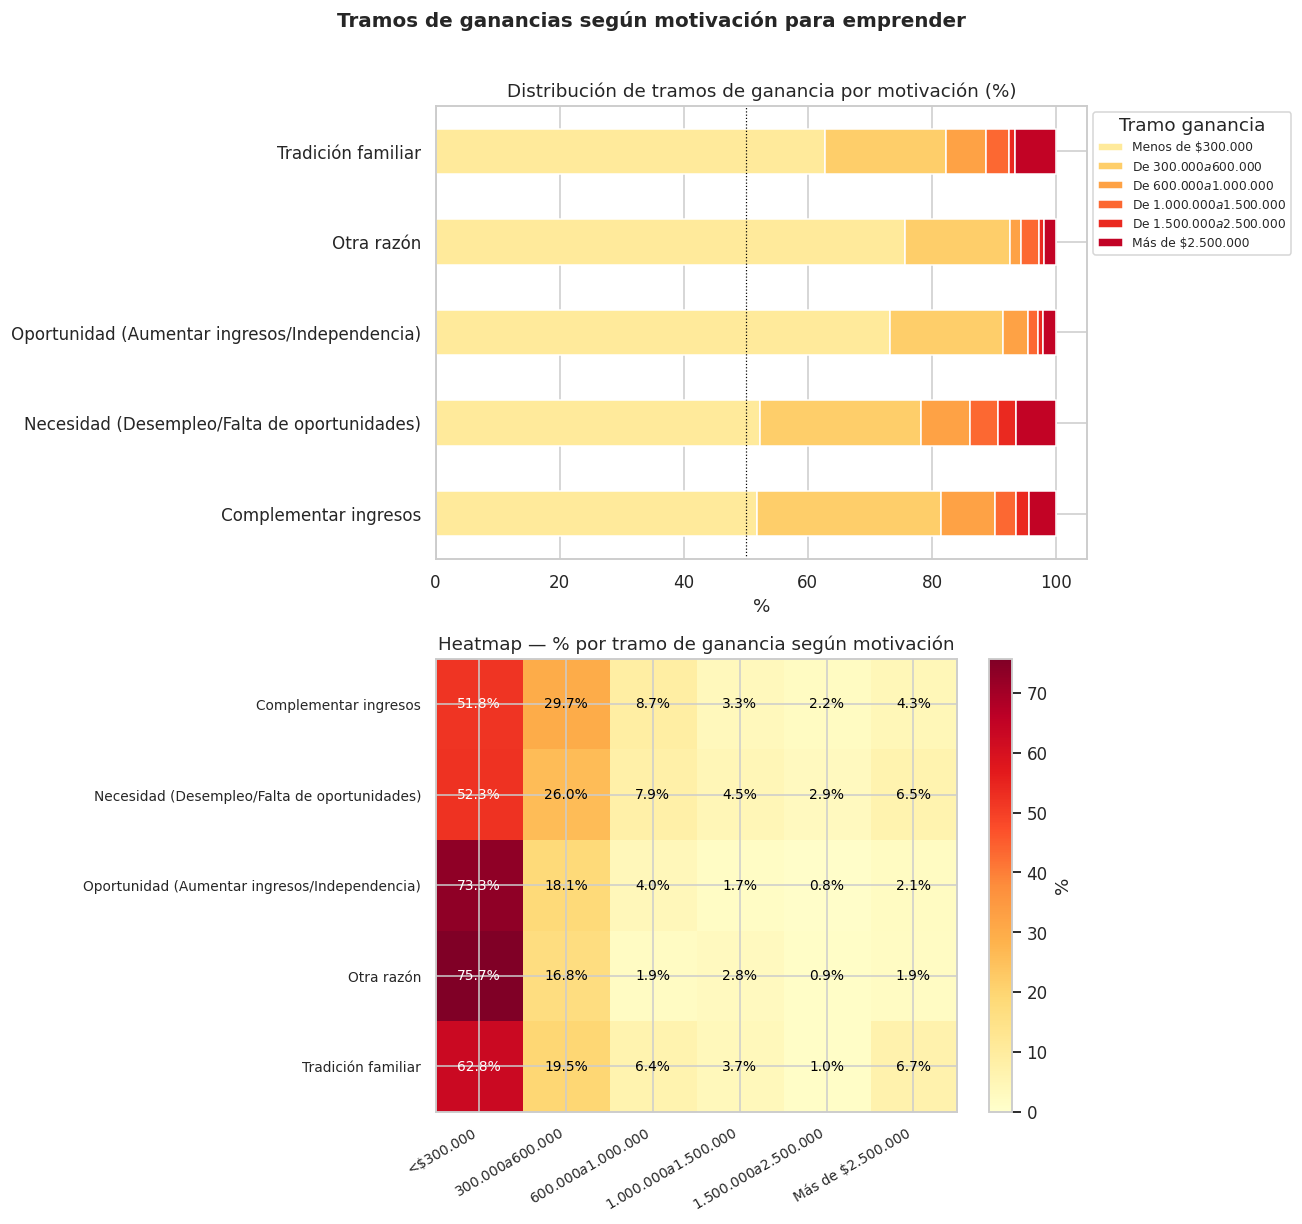


Tabla de % por motivación:


tramos_ganancias,Menos de $300.000,De $300.000 a $600.000,De $600.000 a $1.000.000,De $1.000.000 a $1.500.000,De $1.500.000 a $2.500.000,Más de $2.500.000
motivacion,,,,,,
Complementar ingresos,51.8,29.7,8.7,3.3,2.2,4.3
Necesidad (Desempleo/Falta de oportunidades),52.3,26.0,7.9,4.5,2.9,6.5
Oportunidad (Aumentar ingresos/Independencia),73.3,18.1,4.0,1.7,0.8,2.1
Otra razón,75.7,16.8,1.9,2.8,0.9,1.9
Tradición familiar,62.8,19.5,6.4,3.7,1.0,6.7


In [ ]:
orden_ganancias = [
    'Menos de $300.000', 'De $300.000 a $600.000', 'De $600.000 a $1.000.000',
    'De $1.000.000 a $1.500.000', 'De $1.500.000 a $2.500.000', 'Más de $2.500.000'
]

tbl_mot = (df.dropna(subset=['motivacion', 'tramos_ganancias'])
             .groupby(['motivacion', 'tramos_ganancias'], observed=True)
             .size()
             .unstack('tramos_ganancias', fill_value=0)
             .reindex(columns=orden_ganancias, fill_value=0))

tbl_mot_pct = tbl_mot.div(tbl_mot.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 11))
colores_g = sns.color_palette('YlOrRd', len(orden_ganancias))

# Arriba: barras apiladas %
tbl_mot_pct.plot(kind='barh', stacked=True, ax=axes[0],
                 color=colores_g, edgecolor='white')
axes[0].set_title('Distribución de tramos de ganancia por motivación (%)')
axes[0].set_xlabel('%')
axes[0].set_ylabel('')
axes[0].legend(title='Tramo ganancia', bbox_to_anchor=(1, 1), fontsize=8)
axes[0].axvline(50, color='black', linestyle=':', linewidth=0.8)

# Abajo: heatmap de porcentajes
import matplotlib.colors as mcolors
im = axes[1].imshow(tbl_mot_pct.values, aspect='auto',
                    cmap='YlOrRd', vmin=0, vmax=tbl_mot_pct.values.max())
axes[1].set_xticks(range(len(orden_ganancias)))
axes[1].set_xticklabels(
    [g.replace('De ', '').replace('Menos de ', '<') for g in orden_ganancias],
    rotation=30, ha='right', fontsize=9)
axes[1].set_yticks(range(len(tbl_mot_pct)))
axes[1].set_yticklabels(tbl_mot_pct.index, fontsize=9)
axes[1].set_title('Heatmap — % por tramo de ganancia según motivación')
for i in range(len(tbl_mot_pct)):
    for j in range(len(orden_ganancias)):
        val = tbl_mot_pct.values[i, j]
        color = 'white' if val > tbl_mot_pct.values.max() * 0.6 else 'black'
        axes[1].text(j, i, f'{val:.1f}%', ha='center', va='center',
                     fontsize=9, color=color)
plt.colorbar(im, ax=axes[1], label='%')

plt.suptitle('Tramos de ganancias según motivación para emprender',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nTabla de % por motivación:')
display(tbl_mot_pct.round(1))

### 6.11 Financiamiento inicial por nivel educativo

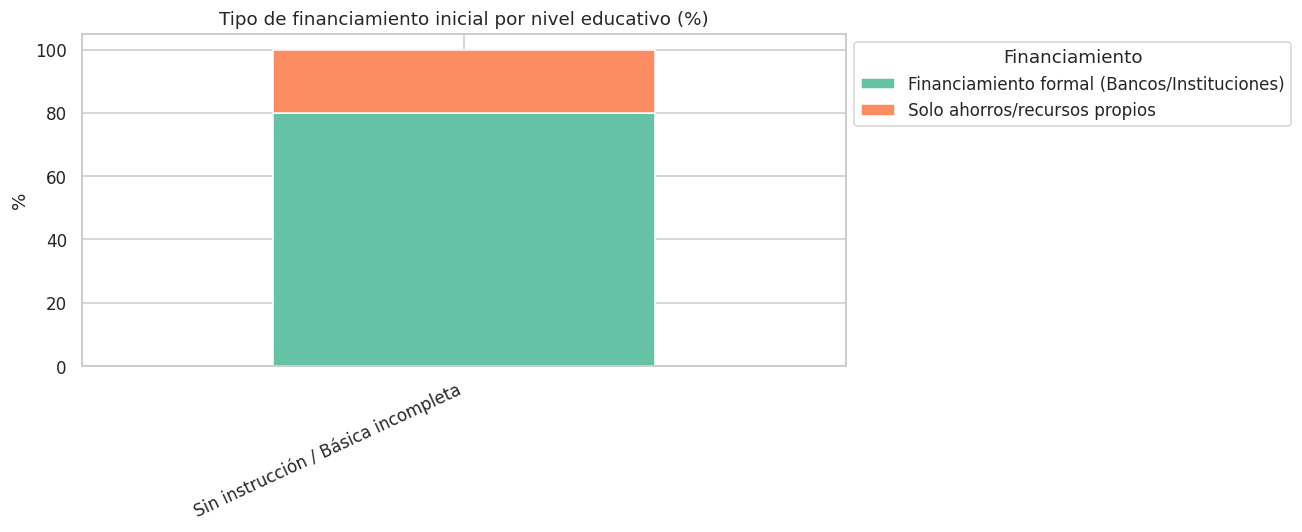

In [ ]:
tbl2 = (df.groupby(['nivel_educativo', 'financiamiento_inicial'])
          .size()
          .unstack(fill_value=0))
tbl2_pct = tbl2.div(tbl2.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
tbl2_pct.plot(kind='bar', stacked=True, ax=ax,
              color=sns.color_palette('Set2', 4), edgecolor='white')
ax.set_title('Tipo de financiamiento inicial por nivel educativo (%)')
ax.set_xlabel('')
ax.set_ylabel('%')
ax.legend(title='Financiamiento', bbox_to_anchor=(1, 1))
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

### 6.12 Lugar de trabajo por sexo

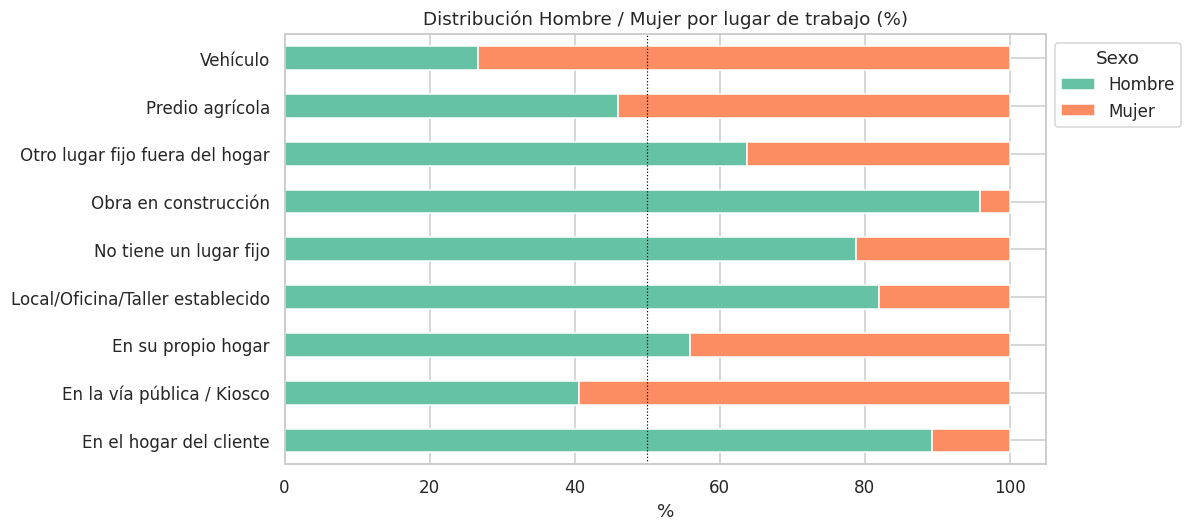

In [ ]:
tbl3 = (df.groupby(['lugar_trabajo', 'sexo'])
          .size()
          .unstack(fill_value=0))
tbl3_pct = tbl3.div(tbl3.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
tbl3_pct.plot(kind='barh', stacked=True, ax=ax,
              color=sns.color_palette('Set2', 2), edgecolor='white')
ax.set_title('Distribución Hombre / Mujer por lugar de trabajo (%)')
ax.set_xlabel('%')
ax.set_ylabel('')
ax.legend(title='Sexo', bbox_to_anchor=(1, 1))
ax.axvline(50, color='black', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

## 7. Resumen estadístico general

In [ ]:
cat_cols = ['region', 'sexo', 'tramo_etario', 'informalidad', 'nivel_educativo',
            'lugar_trabajo', 'financiamiento_inicial', 'motivacion',
            'tramos_ganancias', 'rama_economica']

for col in cat_cols:
    print(f'\n── {col} ─────────────────────────────────────────')
    display(
        df[col].value_counts(dropna=False)
               .rename_axis('valor')
               .reset_index(name='n')
               .assign(pct=lambda x: (x['n'] / len(df) * 100).round(2))
               .head(10)
    )


── region ─────────────────────────────────────────


,valor,n,pct
0,Metropolitana,1284,17.91
1,Valparaíso,725,10.11
2,Biobío,687,9.58
3,Maule,519,7.24
4,La Araucanía,465,6.49
5,Los Lagos,454,6.33
6,Coquimbo,435,6.07
7,Los Ríos,363,5.06
8,Ñuble,350,4.88
9,O'Higgins,348,4.85



── sexo ─────────────────────────────────────────


,valor,n,pct
0,Hombre,4095,57.11
1,Mujer,3075,42.89



── tramo_etario ─────────────────────────────────────────


...

,valor,n,pct
0,Oportunidad (Aumentar ingresos/Independencia),3440,47.98
1,Necesidad (Desempleo/Falta de oportunidades),2230,31.10
2,Tradición familiar,704,9.82
3,NaN,407,5.68
4,Complementar ingresos,276,3.85
5,Otra razón,107,1.49
6,None,6,0.08



── tramos_ganancias ─────────────────────────────────────────


,valor,n,pct
0,Menos de $300.000,4356,60.75
1,De $300.000 a $600.000,1441,20.10
2,NaN,407,5.68
3,De $600.000 a $1.000.000,386,5.38
4,Más de $2.500.000,279,3.89
5,De $1.000.000 a $1.500.000,196,2.73
6,De $1.500.000 a $2.500.000,105,1.46



── rama_economica ─────────────────────────────────────────


,valor,n,pct
0,Suministro de electricidad y agua,1932,26.95
1,Comercio,1811,25.26
2,Explotación de minas,944,13.17
3,"Agricultura, silvicultura y pesca",783,10.92
4,Industrias manufactureras,757,10.56
5,Construcción,536,7.48
6,NaN,407,5.68
